# Customer Churn Prediction in the Telecommunications Industry

This notebook presents an end-to-end machine learning workflow for predicting customer churn in the telecommunications sector using the Telco Customer Churn dataset. The analysis follows a reproducible academic structure: dataset inspection, data cleaning, exploratory data analysis, feature engineering, model training, model comparison, feature selection, and hyperparameter optimization.

The target variable is `Churn`, transformed into a binary label where churned customers are represented as 1 and retained customers as 0. The main practical goal is to identify customers with elevated churn risk while keeping the methodology transparent enough to support interpretation in a seminar report.


## Project Objective

Customer churn prediction is a supervised binary classification problem. Given demographic, subscription, service, and billing information about a customer, the model estimates whether the customer belongs to the churn class.

The technical objectives of this notebook are:

- inspect the dataset structure, data types, missing values, and target distribution;
- clean inconsistent fields and encode the target variable;
- analyze churn patterns using exploratory data analysis;
- construct additional domain-motivated features;
- train and compare several classification algorithms;
- evaluate models using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves;
- perform feature selection and feature-importance analysis;
- tune selected model families with cross-validated hyperparameter optimization.


## Imports and Configuration


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
sns.set_theme(style="white", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True

## Dataset Overview


In [2]:
data_path = Path("../data/telco-customer-churn.csv")

df = pd.read_csv('../data/telco-customer-churn.csv')

print(f"Dataset path: {data_path}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Dataset path: ../data/telco-customer-churn.csv
Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
dataset_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "unique_values": df.nunique(),
    }
)

display(dataset_summary)

,dtype,missing_values,unique_values
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,2
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


In [4]:
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print(f"Standard missing values: {df.isna().sum().sum()}")
print(f"Blank TotalCharges values: {blank_total_charges}")
print(f"Share of rows with blank TotalCharges: {blank_total_charges / len(df):.2%}")

Standard missing values: 0
Blank TotalCharges values: 11
Share of rows with blank TotalCharges: 0.16%


## Data Cleaning

`TotalCharges` is stored as text because a small number of records contain blank strings. After conversion to numeric format, these rows become missing values. Because the affected records represent only 11 of 7043 observations, they are removed rather than imputed. This keeps the preprocessing decision simple and avoids introducing artificial billing values for a tiny subset of customers.


In [5]:
clean_df = df.copy()
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")
clean_df = clean_df.dropna(subset=["TotalCharges"]).copy()

clean_df["ChurnBinary"] = clean_df["Churn"].map({"No": 0, "Yes": 1})

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(clean_df)}")
print(f"Rows removed: {len(df) - len(clean_df)}")
assert len(clean_df) == 7032, "Unexpected cleaned dataset size."
assert clean_df["ChurnBinary"].notna().all(), "Target encoding failed for some rows."

display(clean_df.head())

Original rows: 7043
Cleaned rows: 7032
Rows removed: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Exploratory Data Analysis


,count,percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


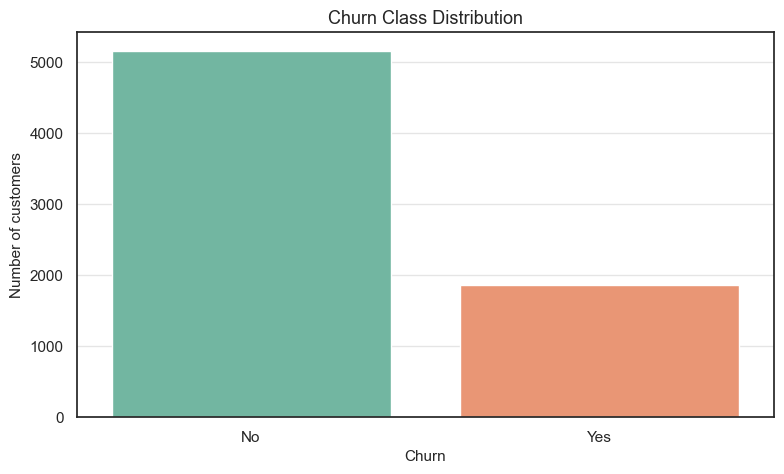

In [6]:
churn_counts = clean_df["Churn"].value_counts()
churn_rates = clean_df["Churn"].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({"count": churn_counts, "percentage": churn_rates}))

ax = sns.countplot(data=clean_df, x="Churn", hue="Churn", legend=False)
ax.set_title("Churn Class Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
plt.show()

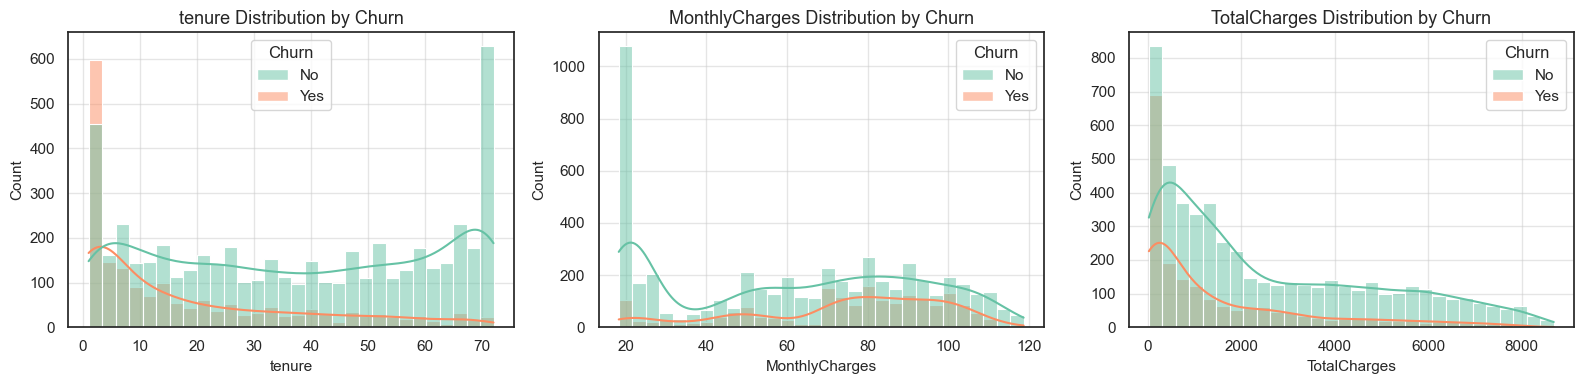

In [7]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, numerical_features, strict=True):
    sns.histplot(data=clean_df, x=feature, hue="Churn", kde=True, bins=30, ax=ax)
    ax.set_title(f"{feature} Distribution by Churn")

plt.tight_layout()
plt.show()

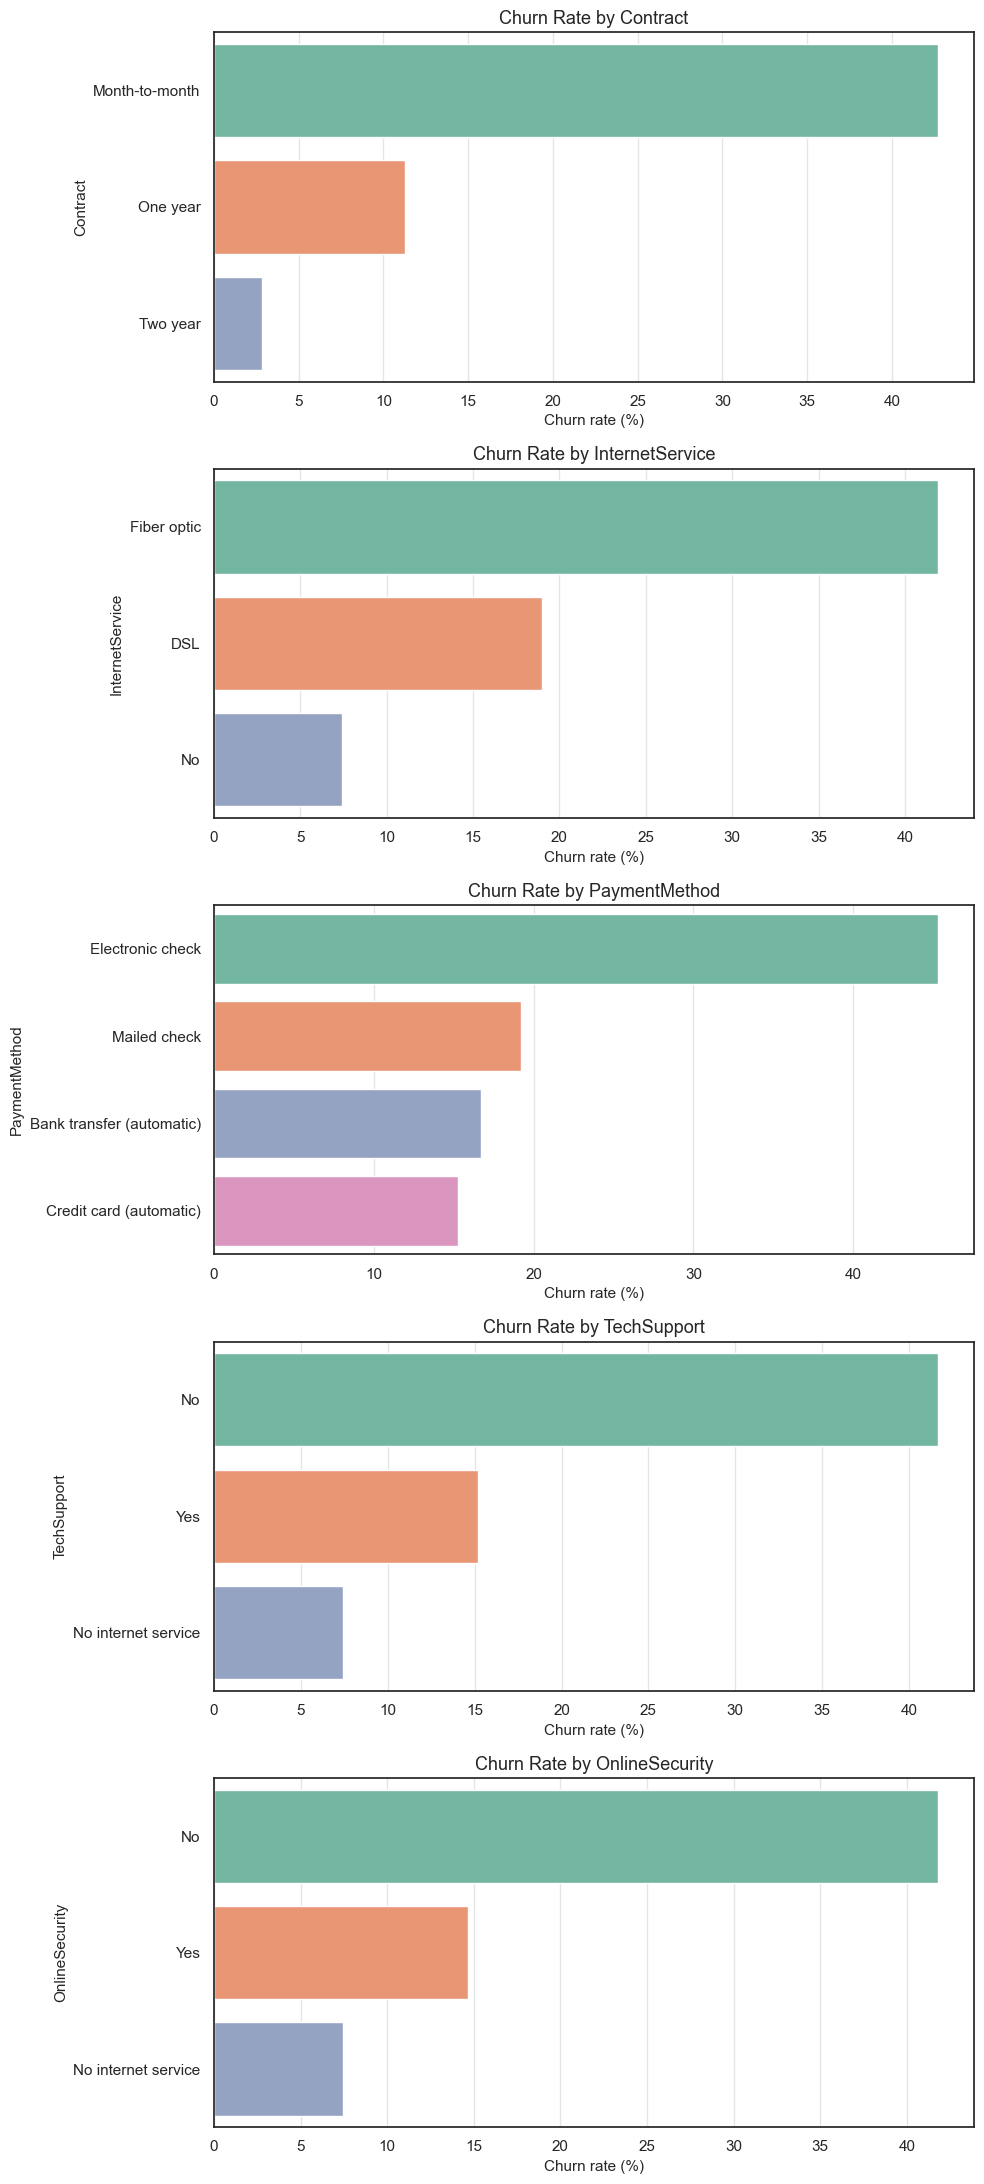

In [8]:
categorical_features_to_compare = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
]

fig, axes = plt.subplots(len(categorical_features_to_compare), 1, figsize=(10, 22))

for ax, feature in zip(axes, categorical_features_to_compare, strict=True):
    churn_rate_by_feature = (
        clean_df.groupby(feature, observed=False)["ChurnBinary"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .reset_index(name="ChurnRate")
    )
    sns.barplot(
        data=churn_rate_by_feature,
        x="ChurnRate",
        y=feature,
        hue=feature,
        ax=ax,
        legend=False,
    )
    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

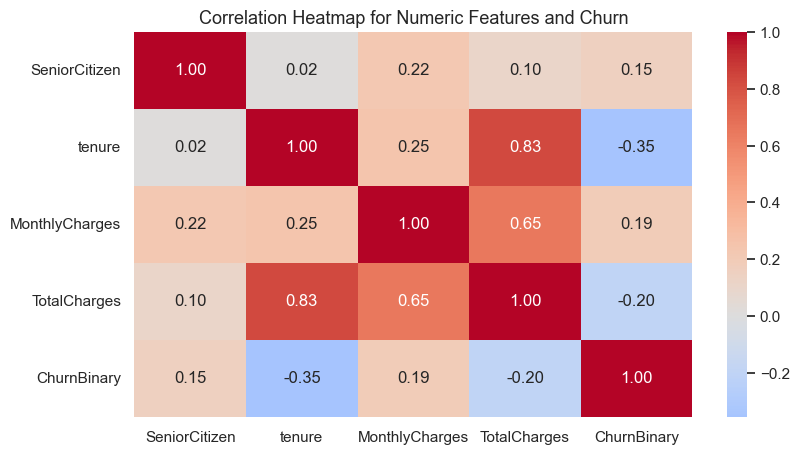

In [9]:
numeric_correlation_df = clean_df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnBinary"]
]

ax = sns.heatmap(
    numeric_correlation_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f"
)
ax.set_title("Correlation Heatmap for Numeric Features and Churn")
plt.show()

## Preprocessing Plan

The dataset contains both numerical and categorical predictors. Numerical variables are standardized, while categorical variables are one-hot encoded. These transformations are placed inside scikit-learn pipelines so that preprocessing is fitted only on the training data during model training and cross-validation. The `customerID` column is excluded because it is an identifier rather than a predictive customer attribute.


In [10]:
target = "ChurnBinary"
excluded_columns = ["customerID", "Churn", target]

X = clean_df.drop(columns=excluded_columns)
y = clean_df[target]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [
    column for column in X.columns if column not in numeric_features
]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Numerical features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Feature matrix shape: (7032, 19)
Target shape: (7032,)
Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Baseline Model

Logistic Regression is used as the first baseline model. It is a good starting point because it is fast, interpretable, and appropriate for binary classification with encoded categorical variables.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

baseline_model.fit(X_train, y_train)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 5625
Test samples: 1407


## Initial Evaluation


In [12]:
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        "Value": [
            accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred),
            roc_auc_score(y_test, y_pred_proba),
        ],
    }
)

display(baseline_metrics.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,Accuracy,0.8045
1,Precision,0.6495
2,Recall,0.5749
3,F1 Score,0.6099
4,ROC-AUC,0.8359


In [13]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



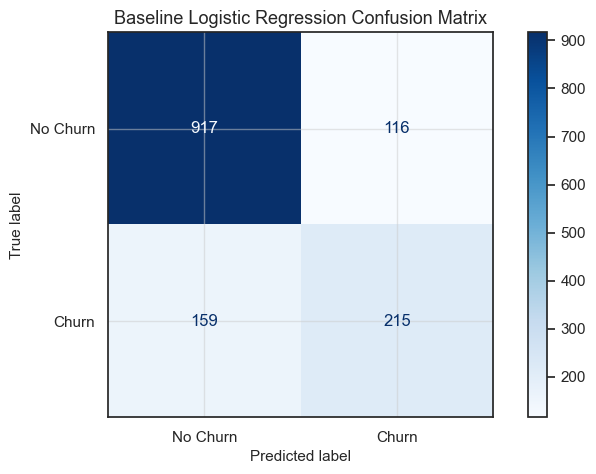

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix, display_labels=["No Churn", "Churn"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

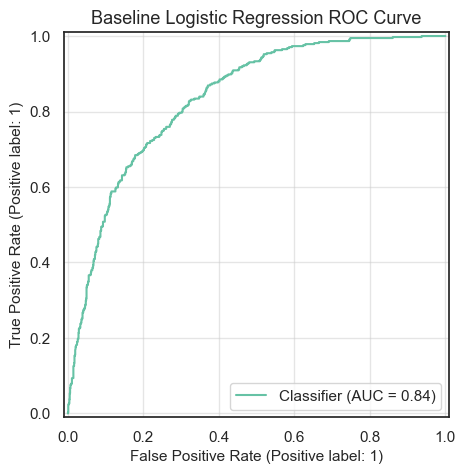

In [15]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title("Baseline Logistic Regression ROC Curve")
plt.show()

## Baseline Findings

The initial Logistic Regression model establishes a simple and interpretable reference point. The dataset is moderately imbalanced, with fewer churned customers than retained customers, so accuracy alone is not enough. Precision, recall, F1-score, and ROC-AUC are more informative because they describe performance on the churn class more directly.

The exploratory plots suggest that contract type, support services, internet service, payment method, tenure, and charges are likely important predictors. The following sections extend the baseline workflow with engineered features, multiple model families, feature selection, and hyperparameter optimization.


## Feature Engineering and Feature Extraction

The original dataset already contains useful customer attributes. Additional features are created to summarize customer tenure, service adoption, online protection usage, streaming usage, and billing intensity. These engineered features are intended to help the models capture higher-level customer behavior.


In [16]:
engineered_df = clean_df.copy()

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

protection_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
]
streaming_columns = ["StreamingTV", "StreamingMovies"]

engineered_df["ServiceCount"] = engineered_df[service_columns].eq("Yes").sum(axis=1)
engineered_df["ProtectionServiceCount"] = (
    engineered_df[protection_columns].eq("Yes").sum(axis=1)
)
engineered_df["HasOnlineProtection"] = np.where(
    engineered_df[protection_columns].eq("Yes").any(axis=1), "Yes", "No"
)
engineered_df["HasStreamingService"] = np.where(
    engineered_df[streaming_columns].eq("Yes").any(axis=1), "Yes", "No"
)
engineered_df["UsesAutomaticPayment"] = np.where(
    engineered_df["PaymentMethod"].str.contains("automatic", case=False), "Yes", "No"
)
engineered_df["IsMonthToMonthContract"] = np.where(
    engineered_df["Contract"].eq("Month-to-month"), "Yes", "No"
)
engineered_df["AverageChargePerTenureMonth"] = engineered_df[
    "TotalCharges"
] / engineered_df["tenure"].replace(0, np.nan)
engineered_df["AverageChargePerTenureMonth"] = engineered_df[
    "AverageChargePerTenureMonth"
].fillna(engineered_df["MonthlyCharges"])

engineered_df["TenureGroup"] = pd.cut(
    engineered_df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True,
)

engineered_df["MonthlyChargeGroup"] = pd.cut(
    engineered_df["MonthlyCharges"],
    bins=[0, 35, 70, 90, np.inf],
    labels=["low", "medium", "high", "very high"],
    include_lowest=True,
)

engineered_features_preview = [
    "tenure",
    "TenureGroup",
    "MonthlyCharges",
    "MonthlyChargeGroup",
    "TotalCharges",
    "AverageChargePerTenureMonth",
    "ServiceCount",
    "ProtectionServiceCount",
    "UsesAutomaticPayment",
    "IsMonthToMonthContract",
    "HasOnlineProtection",
    "HasStreamingService",
    "Churn",
]

display(engineered_df[engineered_features_preview].head())

,tenure,TenureGroup,MonthlyCharges,MonthlyChargeGroup,TotalCharges,AverageChargePerTenureMonth,ServiceCount,ProtectionServiceCount,UsesAutomaticPayment,IsMonthToMonthContract,HasOnlineProtection,HasStreamingService,Churn
0,1,0-12 months,29.85,low,29.85,29.850000,1,1,No,Yes,Yes,No,No
1,34,25-48 months,56.95,medium,1889.50,55.573529,2,2,No,No,Yes,No,No
2,2,0-12 months,53.85,medium,108.15,54.075000,2,2,No,Yes,Yes,No,Yes
3,45,25-48 months,42.30,medium,1840.75,40.905556,3,3,Yes,No,Yes,No,No
4,2,0-12 months,70.70,high,151.65,75.825000,0,0,No,Yes,No,No,Yes


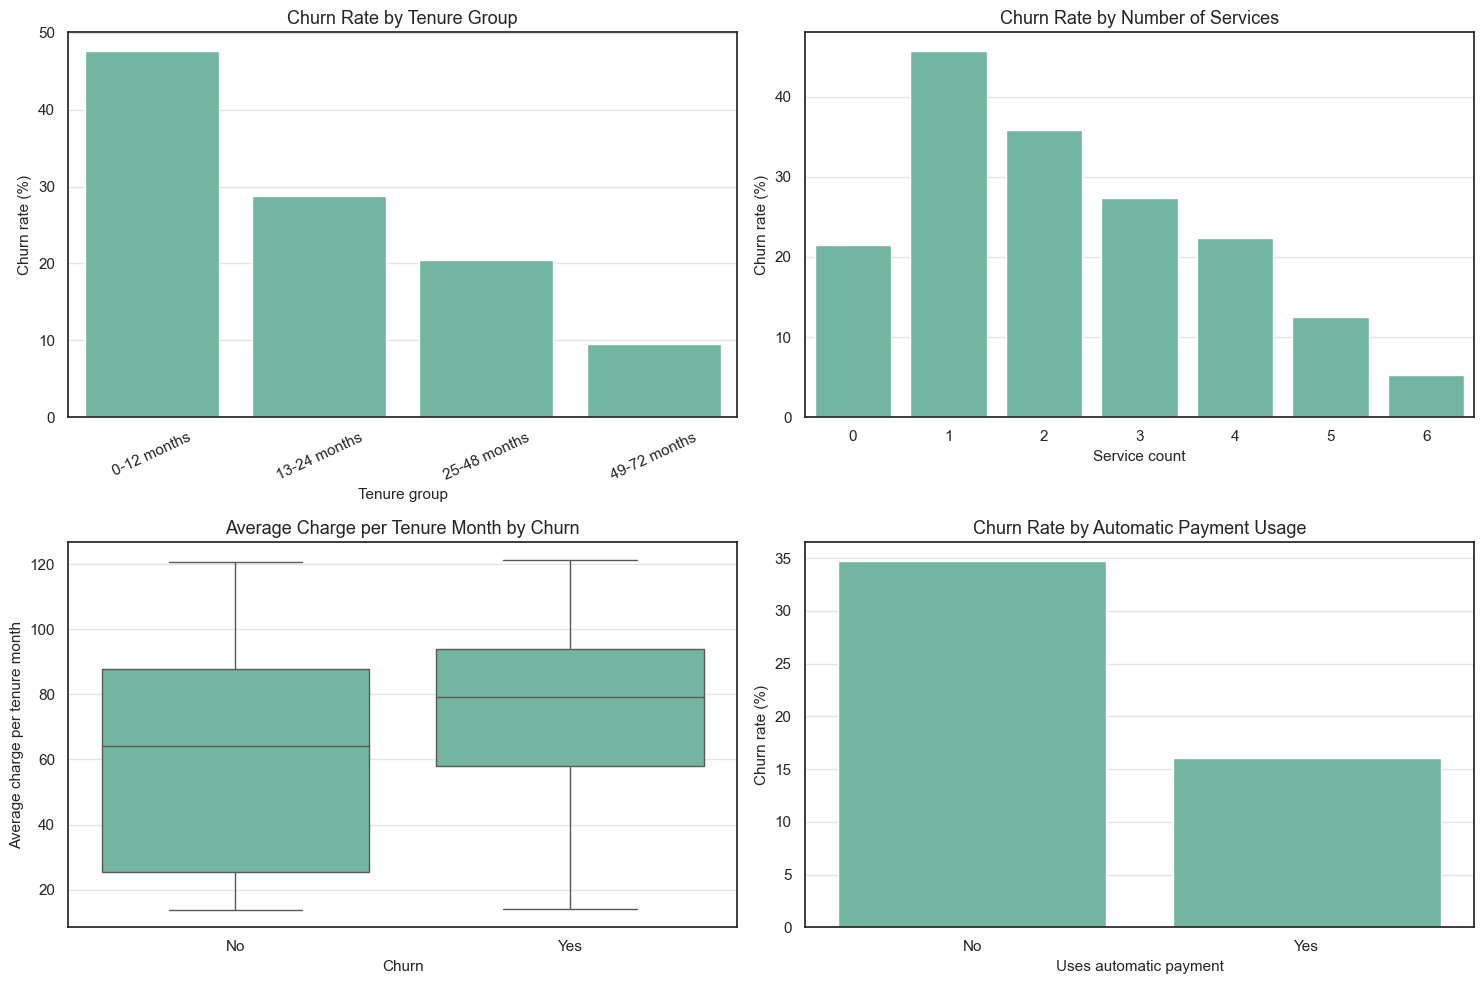

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

sns.barplot(
    data=engineered_df.groupby("TenureGroup", observed=False)["ChurnBinary"]
    .mean()
    .mul(100)
    .reset_index(),
    x="TenureGroup",
    y="ChurnBinary",
    ax=axes[0],
)
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_xlabel("Tenure group")
axes[0].set_ylabel("Churn rate (%)")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(
    data=engineered_df.groupby("ServiceCount", observed=False)["ChurnBinary"]
    .mean()
    .mul(100)
    .reset_index(),
    x="ServiceCount",
    y="ChurnBinary",
    ax=axes[1],
)
axes[1].set_title("Churn Rate by Number of Services")
axes[1].set_xlabel("Service count")
axes[1].set_ylabel("Churn rate (%)")

sns.boxplot(data=engineered_df, x="Churn", y="AverageChargePerTenureMonth", ax=axes[2])
axes[2].set_title("Average Charge per Tenure Month by Churn")
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Average charge per tenure month")

sns.barplot(
    data=engineered_df.groupby("UsesAutomaticPayment", observed=False)["ChurnBinary"]
    .mean()
    .mul(100)
    .reset_index(),
    x="UsesAutomaticPayment",
    y="ChurnBinary",
    ax=axes[3],
)
axes[3].set_title("Churn Rate by Automatic Payment Usage")
axes[3].set_xlabel("Uses automatic payment")
axes[3].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.show()

## Model Comparison Setup

The same preprocessing logic is reused for all candidate models. Numerical features are scaled and categorical features are one-hot encoded. Each pipeline receives its own fresh preprocessing object, which avoids accidental sharing of fitted state between models. The models are evaluated on the same stratified train/test split, so the metrics are directly comparable.


In [18]:
target = "ChurnBinary"
excluded_columns = ["customerID", "Churn", target]

X_engineered = engineered_df.drop(columns=excluded_columns)
y_engineered = engineered_df[target]

numeric_features_engineered = X_engineered.select_dtypes(
    include=["number"]
).columns.tolist()
categorical_features_engineered = [
    column
    for column in X_engineered.columns
    if column not in numeric_features_engineered
]

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_engineered,
)


def make_engineered_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features_engineered),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features_engineered,
            ),
        ],
        verbose_feature_names_out=False,
    )


print(f"Engineered feature matrix shape: {X_engineered.shape}")
print(
    f"Numerical features ({len(numeric_features_engineered)}): {numeric_features_engineered}"
)
print(
    f"Categorical features ({len(categorical_features_engineered)}): {categorical_features_engineered}"
)

Engineered feature matrix shape: (7032, 28)
Numerical features (7): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'ProtectionServiceCount', 'AverageChargePerTenureMonth']
Categorical features (21): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'HasOnlineProtection', 'HasStreamingService', 'UsesAutomaticPayment', 'IsMonthToMonthContract', 'TenureGroup', 'MonthlyChargeGroup']


In [19]:
def make_model_pipeline(estimator):
    return Pipeline(
        steps=[
            ("preprocessor", make_engineered_preprocessor()),
            ("classifier", estimator),
        ]
    )


def predict_scores(model, features):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]

    decision_scores = model.decision_function(features)
    score_range = decision_scores.max() - decision_scores.min()
    if score_range == 0:
        return np.full_like(decision_scores, fill_value=0.5, dtype=float)
    return (decision_scores - decision_scores.min()) / score_range


def evaluate_classifier(name, model, features_test, target_test):
    y_pred_model = model.predict(features_test)
    y_score_model = predict_scores(model, features_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(target_test, y_pred_model),
        "Precision": precision_score(target_test, y_pred_model, zero_division=0),
        "Recall": recall_score(target_test, y_pred_model, zero_division=0),
        "F1 Score": f1_score(target_test, y_pred_model, zero_division=0),
        "ROC-AUC": roc_auc_score(target_test, y_score_model),
    }


candidate_models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Gaussian NB": GaussianNB(),
}

trained_models = {}
model_results = []
cv_scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

for model_name, candidate_classifier in candidate_models.items():
    model_pipeline = make_model_pipeline(candidate_classifier)
    cv_scores = cross_validate(
        model_pipeline,
        X_train_eng,
        y_train_eng,
        scoring=cv_scoring,
        cv=5,
        n_jobs=1,
    )
    model_pipeline.fit(X_train_eng, y_train_eng)
    trained_models[model_name] = model_pipeline
    model_result = evaluate_classifier(
        model_name, model_pipeline, X_test_eng, y_test_eng
    )
    model_result.update(
        {
            "CV Precision Mean": cv_scores["test_precision"].mean(),
            "CV Precision Std": cv_scores["test_precision"].std(),
            "CV Recall Mean": cv_scores["test_recall"].mean(),
            "CV Recall Std": cv_scores["test_recall"].std(),
            "CV F1 Mean": cv_scores["test_f1"].mean(),
            "CV F1 Std": cv_scores["test_f1"].std(),
            "CV ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
            "CV ROC-AUC Std": cv_scores["test_roc_auc"].std(),
        }
    )
    model_results.append(model_result)

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(by=["F1 Score", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    model_comparison.style.format(
        {column: "{:.4f}" for column in model_comparison.columns if column != "Model"}
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Decision Tree,0.7335,0.4991,0.7754,0.6073,0.8173,0.4989,0.0179,0.7759,0.0349,0.6071,0.0213,0.8144,0.0169
1,Gaussian NB,0.7022,0.4654,0.8102,0.5912,0.8088,0.4785,0.0158,0.8247,0.0246,0.6055,0.0173,0.8234,0.0178
2,Logistic Regression,0.7953,0.6361,0.5374,0.5826,0.8342,0.6589,0.0257,0.5318,0.0225,0.5884,0.0222,0.8464,0.0174
3,Gradient Boosting,0.7903,0.6262,0.5241,0.5706,0.8390,0.6625,0.0425,0.5217,0.0242,0.5836,0.0303,0.8461,0.0176
4,KNN,0.7711,0.5714,0.5561,0.5637,0.8149,0.5917,0.0227,0.5458,0.0138,0.5678,0.0168,0.8198,0.0196
5,Random Forest,0.7825,0.6133,0.4920,0.5460,0.8137,0.6336,0.0321,0.4870,0.0331,0.5506,0.0331,0.8284,0.0146
6,SVM,0.7903,0.6458,0.4679,0.5426,0.7880,0.6669,0.0423,0.4957,0.0213,0.5682,0.0244,0.7952,0.0213
7,Dummy Baseline,0.7342,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


## Baseline Versus Engineered Features

The first Logistic Regression baseline used only the cleaned original features. The engineered-feature version uses the same model family but adds domain-derived variables such as tenure groups, service counts, automatic payment usage, and contract indicators.


In [20]:
baseline_logistic_summary = baseline_metrics.set_index("Metric")["Value"].to_dict()
engineered_logistic_summary = evaluate_classifier(
    "Logistic Regression - Engineered Features",
    trained_models["Logistic Regression"],
    X_test_eng,
    y_test_eng,
)

baseline_vs_engineered = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression - Original Features",
            "Accuracy": baseline_logistic_summary["Accuracy"],
            "Precision": baseline_logistic_summary["Precision"],
            "Recall": baseline_logistic_summary["Recall"],
            "F1 Score": baseline_logistic_summary["F1 Score"],
            "ROC-AUC": baseline_logistic_summary["ROC-AUC"],
        },
        engineered_logistic_summary,
    ]
)

display(
    baseline_vs_engineered.style.format(
        {
            column: "{:.4f}"
            for column in baseline_vs_engineered.columns
            if column != "Model"
        }
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression - Original Features,0.8045,0.6495,0.5749,0.6099,0.8359
1,Logistic Regression - Engineered Features,0.7953,0.6361,0.5374,0.5826,0.8342


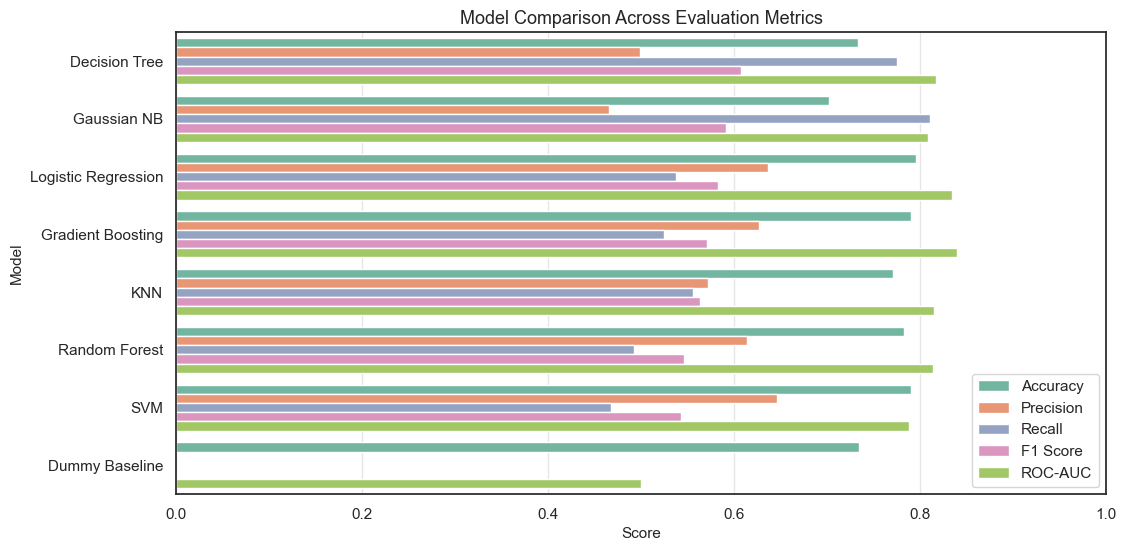

In [21]:
comparison_plot_df = model_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_plot_df, x="Score", y="Model", hue="Metric")
plt.title("Model Comparison Across Evaluation Metrics")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(loc="lower right")
plt.show()

Best model by F1 score: Decision Tree
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



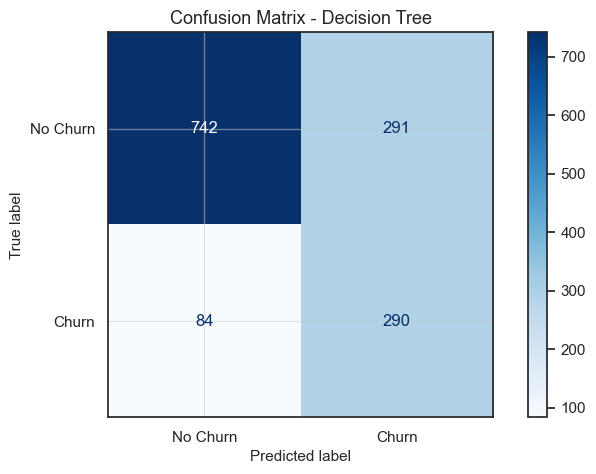

In [22]:
best_model_name = model_comparison.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_y_pred = best_model.predict(X_test_eng)

print(f"Best model by F1 score: {best_model_name}")
print(
    classification_report(y_test_eng, best_y_pred, target_names=["No Churn", "Churn"])
)

ConfusionMatrixDisplay.from_predictions(
    y_test_eng,
    best_y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d",
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Feature Selection

Feature selection is performed on the preprocessed training matrix using mutual information. This identifies transformed features with the strongest statistical relationship to the churn target. A Logistic Regression model is then trained with the selected top features to evaluate whether a smaller feature set can preserve useful predictive performance.


,Feature,Mutual Information
0,IsMonthToMonthContract_Yes,0.1048
1,IsMonthToMonthContract_No,0.1017
2,Contract_Month-to-month,0.0996
3,tenure,0.0777
4,Contract_Two year,0.0636
5,OnlineSecurity_No,0.0620
6,TechSupport_No,0.0553
7,TenureGroup_0-12 months,0.0465
8,PaymentMethod_Electronic check,0.0458
9,MonthlyCharges,0.0454


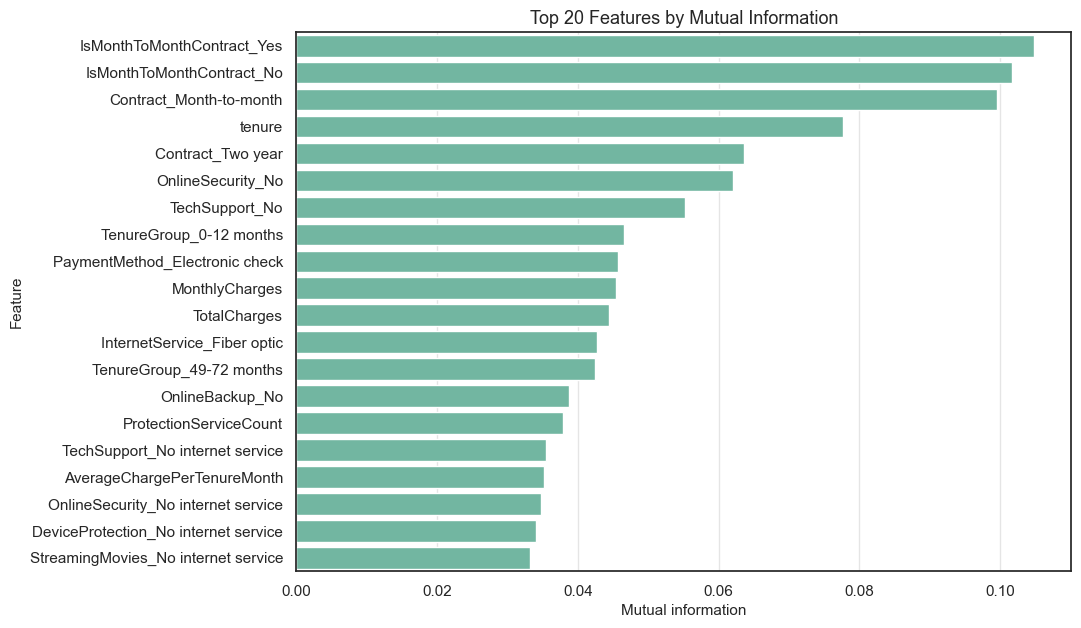

In [23]:
feature_selection_preprocessor = make_engineered_preprocessor()
X_train_processed = feature_selection_preprocessor.fit_transform(X_train_eng)
feature_names = feature_selection_preprocessor.get_feature_names_out()

mutual_information = mutual_info_classif(
    X_train_processed,
    y_train_eng,
    random_state=RANDOM_STATE,
)

feature_selection_table = (
    pd.DataFrame({"Feature": feature_names, "Mutual Information": mutual_information})
    .sort_values("Mutual Information", ascending=False)
    .reset_index(drop=True)
)

display(feature_selection_table.head(20).style.format({"Mutual Information": "{:.4f}"}))

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_selection_table.head(20), x="Mutual Information", y="Feature")
plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual information")
plt.ylabel("Feature")
plt.show()

In [24]:
top_k = min(20, len(feature_names))

selected_feature_model = Pipeline(
    steps=[
        ("preprocessor", make_engineered_preprocessor()),
        ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=top_k)),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

selected_feature_model.fit(X_train_eng, y_train_eng)
selected_feature_metrics = evaluate_classifier(
    f"Logistic Regression - Top {top_k} Features",
    selected_feature_model,
    X_test_eng,
    y_test_eng,
)

selected_vs_full = pd.DataFrame(
    [
        evaluate_classifier(
            "Logistic Regression - Full Features",
            trained_models["Logistic Regression"],
            X_test_eng,
            y_test_eng,
        ),
        selected_feature_metrics,
    ]
)

display(
    selected_vs_full.style.format(
        {column: "{:.4f}" for column in selected_vs_full.columns if column != "Model"}
    )
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression - Full Features,0.7953,0.6361,0.5374,0.5826,0.8342
1,Logistic Regression - Top 20 Features,0.7903,0.6321,0.5053,0.5617,0.8327


## Feature Importance

Tree-based models provide another view of feature relevance. The Random Forest model is used to estimate feature importance after preprocessing. This gives a practical ranking of which encoded customer attributes contributed most to the model.


,Feature,Importance
0,TotalCharges,0.0983
1,AverageChargePerTenureMonth,0.0911
2,MonthlyCharges,0.0871
3,tenure,0.0835
4,Contract_Month-to-month,0.0539
5,IsMonthToMonthContract_No,0.0428
6,IsMonthToMonthContract_Yes,0.0428
7,OnlineSecurity_No,0.0255
8,TechSupport_No,0.0229
9,Contract_Two year,0.0195


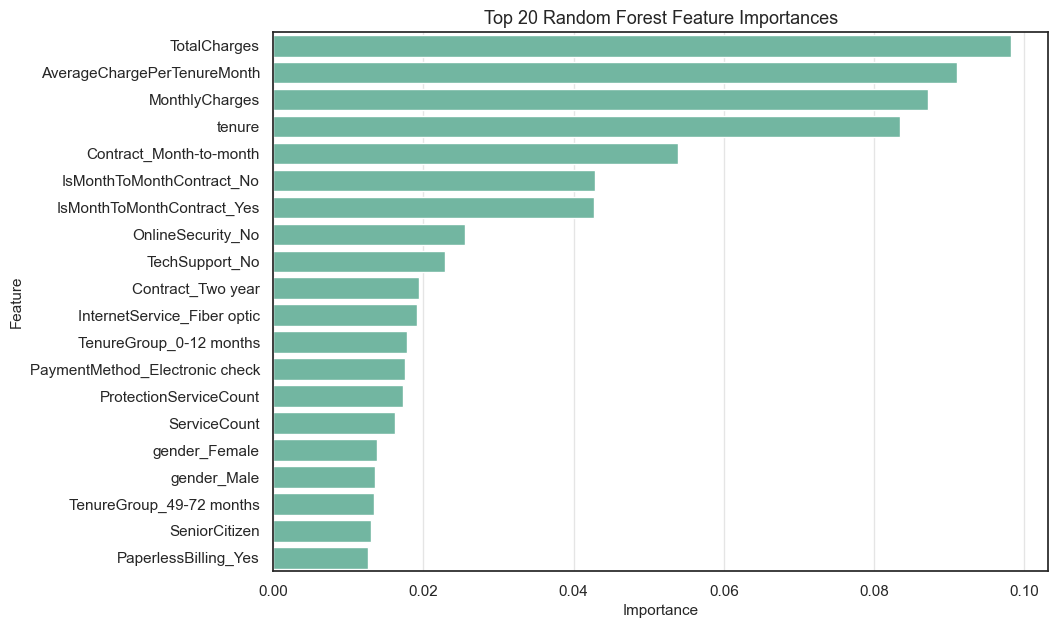

In [25]:
random_forest_model = trained_models["Random Forest"]
rf_classifier = random_forest_model.named_steps["classifier"]
rf_feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

rf_importance_table = (
    pd.DataFrame(
        {"Feature": rf_feature_names, "Importance": rf_classifier.feature_importances_}
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance_table.head(20).style.format({"Importance": "{:.4f}"}))

plt.figure(figsize=(10, 7))
sns.barplot(data=rf_importance_table.head(20), x="Importance", y="Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Hyperparameter Optimization

The strongest candidate families from the initial comparison are optimized using cross-validation. Random Forest and Gradient Boosting are tuned because they perform well on mixed tabular data and can model non-linear relationships between customer attributes and churn. The optimization metric is F1-score, which balances precision and recall for the minority churn class.


In [26]:
rf_tuning_pipeline = make_model_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
)
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 8, 14],
    "classifier__min_samples_split": [2, 10],
    "classifier__class_weight": [None, "balanced"],
}

gb_tuning_pipeline = make_model_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE)
)
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3],
}

tuning_searches = {
    "Tuned Random Forest": GridSearchCV(
        estimator=rf_tuning_pipeline,
        param_grid=rf_param_grid,
        scoring="f1",
        cv=5,
        n_jobs=1,
    ),
    "Tuned Gradient Boosting": GridSearchCV(
        estimator=gb_tuning_pipeline,
        param_grid=gb_param_grid,
        scoring="f1",
        cv=5,
        n_jobs=1,
    ),
}

tuned_models = {}
tuning_results = []

for search_name, search in tuning_searches.items():
    search.fit(X_train_eng, y_train_eng)
    tuned_models[search_name] = search.best_estimator_
    result = evaluate_classifier(
        search_name, search.best_estimator_, X_test_eng, y_test_eng
    )
    result["Best CV F1"] = search.best_score_
    result["Best Parameters"] = search.best_params_
    tuning_results.append(result)

hyperparameter_results = (
    pd.DataFrame(tuning_results)
    .sort_values(
        by=["F1 Score", "ROC-AUC"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    hyperparameter_results.drop(columns="Best Parameters").style.format(
        {
            column: "{:.4f}"
            for column in hyperparameter_results.drop(columns="Best Parameters").columns
            if column != "Model"
        }
    )
)

for _, row in hyperparameter_results.iterrows():
    print(f"{row['Model']} best parameters:")
    print(row["Best Parameters"])
    print()

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Best CV F1
0,Tuned Random Forest,0.7456,0.5143,0.7701,0.6167,0.8333,0.6343
1,Tuned Gradient Boosting,0.7932,0.6361,0.5187,0.5714,0.8389,0.5850


Tuned Random Forest best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 400}

Tuned Gradient Boosting best parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
0,Tuned Random Forest,0.7456,0.5143,0.7701,0.6167,0.8333,nan,nan,nan,nan,nan,nan,nan,nan
1,Decision Tree,0.7335,0.4991,0.7754,0.6073,0.8173,0.4989,0.0179,0.7759,0.0349,0.6071,0.0213,0.8144,0.0169
2,Gaussian NB,0.7022,0.4654,0.8102,0.5912,0.8088,0.4785,0.0158,0.8247,0.0246,0.6055,0.0173,0.8234,0.0178
3,Logistic Regression,0.7953,0.6361,0.5374,0.5826,0.8342,0.6589,0.0257,0.5318,0.0225,0.5884,0.0222,0.8464,0.0174
4,Tuned Gradient Boosting,0.7932,0.6361,0.5187,0.5714,0.8389,nan,nan,nan,nan,nan,nan,nan,nan
5,Gradient Boosting,0.7903,0.6262,0.5241,0.5706,0.8390,0.6625,0.0425,0.5217,0.0242,0.5836,0.0303,0.8461,0.0176
6,KNN,0.7711,0.5714,0.5561,0.5637,0.8149,0.5917,0.0227,0.5458,0.0138,0.5678,0.0168,0.8198,0.0196
7,Logistic Regression - Top 20 Features,0.7903,0.6321,0.5053,0.5617,0.8327,nan,nan,nan,nan,nan,nan,nan,nan
8,Random Forest,0.7825,0.6133,0.4920,0.5460,0.8137,0.6336,0.0321,0.4870,0.0331,0.5506,0.0331,0.8284,0.0146
9,SVM,0.7903,0.6458,0.4679,0.5426,0.7880,0.6669,0.0423,0.4957,0.0213,0.5682,0.0244,0.7952,0.0213


Final best model by test F1 score: Tuned Random Forest
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.51      0.77      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407



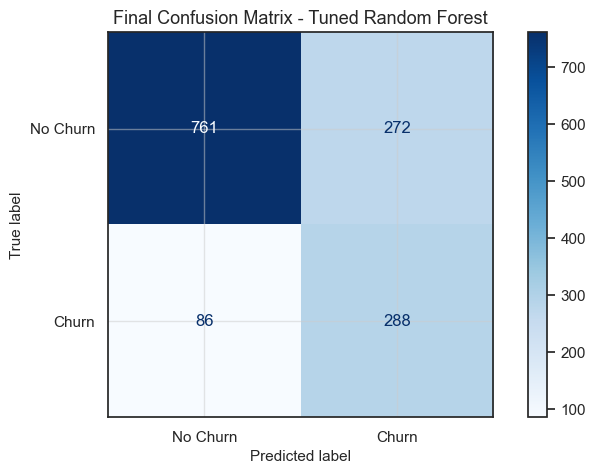

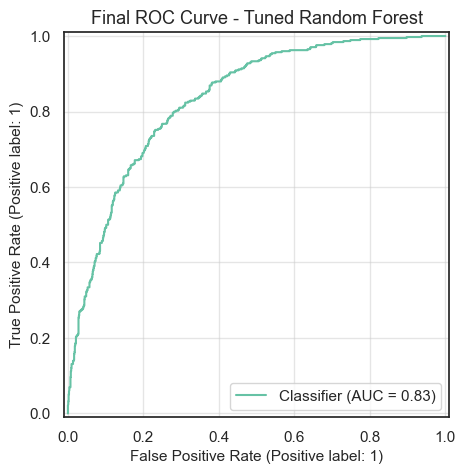

In [27]:
final_comparison = (
    pd.concat(
        [
            model_comparison,
            hyperparameter_results.drop(columns=["Best CV F1", "Best Parameters"]),
            selected_vs_full[selected_vs_full["Model"].str.contains("Top")],
        ],
        ignore_index=True,
    )
    .sort_values(by=["F1 Score", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

display(
    final_comparison.style.format(
        {column: "{:.4f}" for column in final_comparison.columns if column != "Model"}
    )
)

final_best_model_name = final_comparison.loc[0, "Model"]
if final_best_model_name in tuned_models:
    final_best_model = tuned_models[final_best_model_name]
elif final_best_model_name == f"Logistic Regression - Top {top_k} Features":
    final_best_model = selected_feature_model
else:
    final_best_model = trained_models[final_best_model_name]

final_y_pred = final_best_model.predict(X_test_eng)
final_y_score = predict_scores(final_best_model, X_test_eng)

print(f"Final best model by test F1 score: {final_best_model_name}")
print(
    classification_report(y_test_eng, final_y_pred, target_names=["No Churn", "Churn"])
)

ConfusionMatrixDisplay.from_predictions(
    y_test_eng,
    final_y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d",
)
plt.title(f"Final Confusion Matrix - {final_best_model_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test_eng, final_y_score)
plt.title(f"Final ROC Curve - {final_best_model_name}")
plt.show()

## Methodology Summary and Limitations

A stratified train/test split is used to preserve the churn ratio in both subsets. All model-specific preprocessing is wrapped inside pipelines, so transformations are learned from the training data during fitting and cross-validation. Accuracy is reported, but it is not enough on its own because the churn class is smaller and more important for the business problem. Recall and F1-score are therefore emphasized when comparing models.

The final model choice should balance predictive performance and interpretability. Logistic Regression is easier to explain, while ensemble models such as Random Forest and Gradient Boosting can capture more complex relationships. The main limitation of this public dataset is that it is a static customer snapshot; it does not include detailed time-series behavior, recent interactions, retention-campaign history, or deployment drift that would matter in a production churn system.

The engineered grouping variables use fixed, interpretable bands rather than target-informed categories. In a production-grade system, feature engineering would still be packaged as reusable pipeline code and validated on newer customer cohorts to test temporal robustness.
